## Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append("../")

from models_training.train_segmentation import *


INPUT_PATH  = "../data/silver/silver_data"
OUTPUT_PATH = "../data/silver/segment_data"
MODEL_PATH  = "../models/kmeans_model"

## Charger les donnees

In [2]:
spark = create_spark()
df    = load_data(spark, INPUT_PATH)
df    = cast_numeric_columns(df)

df.show(5)

26/03/14 23:47:06 WARN Utils: Your hostname, nouhayla-HP-EliteBook-835-G7-Notebook-PC resolves to a loopback address: 127.0.1.1; using 192.168.1.182 instead (on interface wlp1s0)
26/03/14 23:47:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/14 23:47:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+----------+----+------+--------+---------------+------------+------------------+-------------------+-------------+------------------+------------------+------------+----------+-----------+-----------------+-------------+-------------------+---------------+----------+
|CustomerID| Age|Gender|  Income|CampaignChannel|CampaignType|           AdSpend|   ClickThroughRate|WebsiteVisits|     PagesPerVisit|        TimeOnSite|SocialShares|EmailOpens|EmailClicks|PreviousPurchases|LoyaltyPoints|AdvertisingPlatform|AdvertisingTool|Conversion|
+----------+----+------+--------+---------------+------------+------------------+-------------------+-------------+------------------+------------------+------------+----------+-----------+-----------------+-------------+-------------------+---------------+----------+
|      8000|56.0|Female|136912.0|   Social Media|   Awareness| 6497.870068417766|0.04391851073538301|          0.0| 2.399016527783845|7.3968025807960585|        19.0|       6.0|        9.0|    

## Trouver le bon K (elbow method)

26/03/14 23:47:16 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/03/14 23:47:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/03/14 23:47:20 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


  K=2 → Cost=111,962
  K=3 → Cost=108,348
  K=4 → Cost=106,319
  K=5 → Cost=103,773
  K=6 → Cost=102,477
  K=7 → Cost=100,324
  K=8 → Cost=99,268


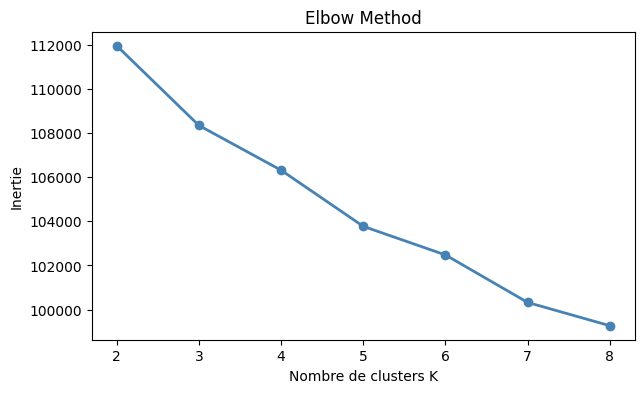

In [ ]:
df_scaled = prepare_for_elbow(df)
costs     = compute_elbow_costs(df_scaled, k_min=2, k_max=8)

# Afficher le graphique
ks, vals = zip(*costs)
plt.figure(figsize=(7, 4))
plt.plot(ks, vals, marker='o', color='steelblue', linewidth=2)
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie")
plt.title("Elbow Method")
plt.show()

## Entrainement du modele

In [4]:
K = 4
model = train_model(df, k=K)
print(f" modele entraine avec K={K}")

 modele entraine avec K=4


## Evaluer le modele
> **Silhouette Score** : entre -1 et 1
> -  > 0.5 → bons clusters
> -  0.25 à 0.5 → acceptable
> -  < 0.25 → essaie un autre K

In [5]:
score = evaluate_model(model, df)
print(f"Silhouette Score = {score:.4f}")

Silhouette Score = 0.0766


## Analyser les segments (centroïdes)
> Chaque ligne = un segment. Chaque colonne = la valeur **moyenne** dans ce segment
> Utilise ce tableau pour décider des noms à l'étape suivante

In [6]:
centers = get_cluster_centers(model)

# Afficher sous forme de tableau
centers_df = pd.DataFrame(centers).T
centers_df.index.name = "SegmentID"
centers_df

,Age,Income,AdSpend,ClickThroughRate,LoyaltyPoints,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,Gender_index,CampaignChannel_index,CampaignType_index
SegmentID,,,,,,,,,,,,,,,
0,-0.43,-0.55,-0.19,-0.35,-0.12,0.01,0.16,0.00,0.14,0.20,0.28,0.07,-0.80,0.39,0.08
1,0.49,0.35,0.25,-0.30,0.34,0.22,-0.21,-0.22,0.44,-0.21,-0.19,-0.02,-0.77,-0.37,-0.12
2,-0.02,-0.08,-0.01,-0.02,0.01,0.02,0.00,-0.03,0.02,-0.02,0.03,0.01,1.24,0.03,0.03
3,0.01,0.40,-0.03,0.78,-0.26,-0.29,0.04,0.30,-0.68,0.02,-0.17,-0.08,-0.71,-0.11,-0.03


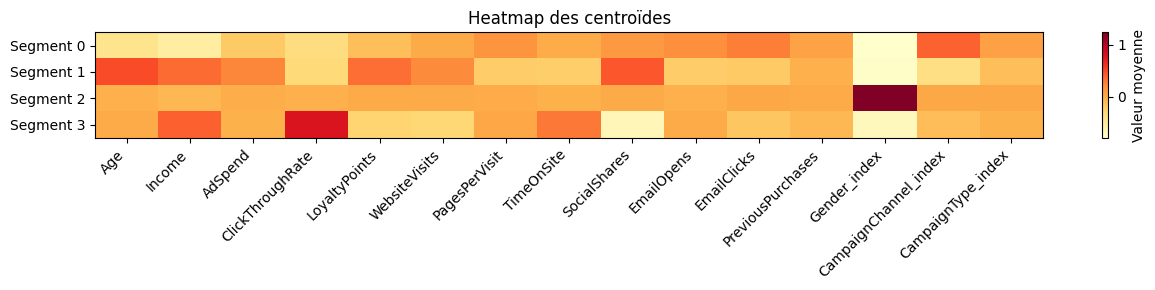

In [7]:
# Heatmap : plus c'est foncé = valeur plus élevée dans ce segment

plt.figure(figsize=(13, 3))
plt.imshow(centers_df.values, aspect='auto', cmap='YlOrRd')
plt.xticks(range(len(KMEANS_FEATURES)), KMEANS_FEATURES, rotation=45, ha='right')
plt.yticks(range(K), [f"Segment {i}" for i in range(K)])
plt.colorbar(label="Valeur moyenne")
plt.title("Heatmap des centroïdes")
plt.tight_layout()
plt.show()

## Nommer les segments
> **Modifie les noms** selon ce que tu vois dans le tableau/heatmap ci-dessus.
>
> Exemples de noms : `High_Value`, `Young_Low_Budget`, `Loyal_Customer`, `Passive_User`...

In [10]:
segment_names = {
    0: "Low_Engagement",
    1: "High_Income_Senior",
    2: "High_Spender_Female",
    3: "Engaged_Clicker"
}


for seg_id, name in segment_names.items():
    print(f"  Segment {seg_id} → {name}")

  Segment 0 → Low_Engagement
  Segment 1 → High_Income_Senior
  Segment 2 → High_Spender_Female
  Segment 3 → Engaged_Clicker


## Sauvegarde

In [11]:
save_data(model, df, segment_names, OUTPUT_PATH)
print("donnees sauvegardees")

save_model(model, MODEL_PATH)
print("modele sauvegarde")

donnees sauvegardees
modele sauvegarde
